In [1]:
#import nmixup
import mix_utils

import numpy as np
import torch
import torchvision
import PIL
import matplotlib.pyplot as plt


In [2]:
BATCH_SIZE = 100
NUM_WORKERS = 8

transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])

base_trainset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=False, download=True, transform=transform)


Files already downloaded and verified
Files already downloaded and verified


In [3]:
def pmix_masks(n, im_dim, single):
    """ Makes pmix masks
    Args:
        n: int, the number of masks to make (one for each unique label)
        im_dim: tuple, width and height of images and thus masks
        single: bool, when activated this function will return the same mask for each label
    Return:
        np.array of shape [n, im_dim[0], im_dim[1]], the list of masks for respective labels
    """
    masks = np.zeros((n, *im_dim), dtype=int)
    for i in range(masks.shape[0]):
        if single and i > 0:
            masks[i] = masks[0]
            continue
        rrange = np.arange(0, im_dim[0]*im_dim[1])
        np.random.shuffle(rrange)
        masks[i] = rrange.reshape(im_dim)
        #masks[i, 0:16, :] = masks[i, 16:32, :]
    return masks

def pmix_images(imgs, labels, masks):
    H, W = masks[0].shape
    
    # Makes empty result array
    pmixed = np.zeros(imgs.shape)
    for i in range(imgs.shape[0]):
        # Flatten mask for this label
        rs_mask = masks[labels[i]].reshape(W * H)
        # Flatten image
        rs_img = imgs[i].reshape((-1, W * H))
        # Mix pixels of img according to mask, accross each channel
        rs_result = rs_img[:, rs_mask]
    
        pmixed[i] = rs_result.reshape((-1, W, H))
    return pmixed

In [4]:
class PmixCifar10(torch.utils.data.Dataset):

    def __init__(self, base_set, pmix_seed, *, single_mask=True, preset_masks=None, sample_size=None, transform=None):
        print("b")
        self.transform = transform        
        
        L = sample_size if sample_size else base_set.data.shape[0]
        imgs = np.array(base_set.data[:L])
        
        print("c")
        imgs = np.float32(imgs/255.)
        imgs = imgs.transpose((0, 3, 1, 2))
        
        print("d")
        labels = np.array(base_set.targets[:L])
        unique = np.unique(labels)
        n_unique = unique.shape[0]
        print("Labels:", unique, "=> n_unique:", n_unique)

        print("g")
        self.pmix_masks = pmix_masks(n_unique, imgs.shape[2:4], single_mask) if preset_masks is None else preset_masks
        self.pmixed = pmix_images(imgs, labels, self.pmix_masks)
        self.labels = labels
        #show_np_array(mixed[0])
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        img = self.pmixed[idx]
        target = self.labels[idx]
        
        if self.transform is not None:
            img = self.transform(img).transpose(1, 0).transpose(1, 2)
            if not img.shape == (3, 32, 32):
                raise Exception()
        return img, target

a
b
c
d
Labels: [0 1 2 3 4 5 6 7 8 9] => n_unique: 10
g
class: automobile


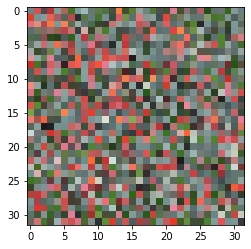

In [5]:
print("a")
trainset = PmixCifar10(base_trainset,
                                2019,
                                sample_size=50000,
                                transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

for imgs, targets in trainloader:
    print("class:", base_trainset.classes[targets[0]])
    mix_utils.show_np_array(imgs[0])
    break

### Training on Pmixed images

In [6]:

from nmixup import resnet18, get_print
model_getter = resnet18

USE_CUDA = True
N_BATCHES = None
N_EPOCHS = 100
N_BATCHES_IN_TRAIN_SET = len(trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(testset) // BATCH_SIZE
print(N_BATCHES_IN_TRAIN_SET, N_BATCHES_IN_TEST_SET)
LR = .05



500 100


In [7]:
base_testset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=False, download=True, transform=transform)


Files already downloaded and verified


In [8]:
testset = PmixCifar10(base_testset, 2019, preset_masks=trainset.pmix_masks, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


b
c
d
Labels: [0 1 2 3 4 5 6 7 8 9] => n_unique: 10
g


In [9]:

test_accs = {}

for i in range(4):
    print_ = get_print(True, fname="results_pmix2_"+str(i))

    device = torch.device('cuda' if USE_CUDA else 'cpu')
    model = model_getter().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = torch.nn.CrossEntropyLoss()


    model.train()

    for epoch in range(1, N_EPOCHS + 1):
        print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
        for batch_id, (images, labels) in enumerate(trainloader):
            if N_BATCHES and batch_id > N_BATCHES:
                break
            labels, images = labels.to(device), images.to(device)
            outputs = model(images.float())
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if batch_id % 50 == 0:
                print_('Loss :{:.4f} Epoch[{}/{}] Batch[{}/{}] batch_shape:{}'.format(
                    loss.item(), epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET, images.shape))

    # switch to evaluate mode
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images.float())
            predicted = torch.argmax(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        # Output test accuracy
        test_acc = 100 * correct / total
        print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))

        test_acc = test_acc

    del device, model, optimizer, criterion


Epoch[1/100]
Loss :2.4425 Epoch[1/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.2330 Epoch[1/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.1570 Epoch[1/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.1031 Epoch[1/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.1533 Epoch[1/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.0447 Epoch[1/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.0492 Epoch[1/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.9481 Epoch[1/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.9469 Epoch[1/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.0664 Epoch[1/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[2/100]
Loss :1.8302 Epoch[2/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.8416 Epoch[2/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 3

Loss :0.9553 Epoch[10/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[11/100]
Loss :0.8084 Epoch[11/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8650 Epoch[11/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.7553 Epoch[11/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8785 Epoch[11/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8210 Epoch[11/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9965 Epoch[11/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.7967 Epoch[11/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.9141 Epoch[11/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0386 Epoch[11/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.8853 Epoch[11/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[12/100]
Loss :0.6410 Epoch[12/100] Batch[0/500] batch_shape:torch.Size

Loss :0.4144 Epoch[20/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.2116 Epoch[20/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1611 Epoch[20/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[21/100]
Loss :0.1590 Epoch[21/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1487 Epoch[21/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1220 Epoch[21/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1418 Epoch[21/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.2196 Epoch[21/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1821 Epoch[21/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1387 Epoch[21/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1988 Epoch[21/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.2421 Epoch[21/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32

Loss :0.0552 Epoch[30/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0754 Epoch[30/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1464 Epoch[30/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1312 Epoch[30/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1242 Epoch[30/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[31/100]
Loss :0.1421 Epoch[31/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0709 Epoch[31/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0612 Epoch[31/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0743 Epoch[31/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0242 Epoch[31/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1312 Epoch[31/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.2004 Epoch[31/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32

Loss :0.1416 Epoch[40/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0903 Epoch[40/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0795 Epoch[40/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0725 Epoch[40/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0622 Epoch[40/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1134 Epoch[40/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1310 Epoch[40/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[41/100]
Loss :0.0318 Epoch[41/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0852 Epoch[41/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0382 Epoch[41/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0310 Epoch[41/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0144 Epoch[41/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32

...

Epoch[54/100]
Loss :0.0258 Epoch[54/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0411 Epoch[54/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0544 Epoch[54/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0402 Epoch[54/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0268 Epoch[54/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0348 Epoch[54/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1301 Epoch[54/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0736 Epoch[54/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0421 Epoch[54/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0594 Epoch[54/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[55/100]
Loss :0.0179 Epoch[55/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0835 Epoch[55/100] Batch[50/500] batch_shape:torch.Size(

Loss :0.0039 Epoch[63/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0088 Epoch[63/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[64/100]
Loss :0.0436 Epoch[64/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0340 Epoch[64/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0037 Epoch[64/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1147 Epoch[64/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0252 Epoch[64/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0485 Epoch[64/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1850 Epoch[64/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0375 Epoch[64/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0132 Epoch[64/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0638 Epoch[64/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32

Loss :0.0194 Epoch[73/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1076 Epoch[73/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0080 Epoch[73/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0282 Epoch[73/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[74/100]
Loss :0.0598 Epoch[74/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0167 Epoch[74/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0137 Epoch[74/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0623 Epoch[74/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0911 Epoch[74/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0592 Epoch[74/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0368 Epoch[74/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0344 Epoch[74/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32

Loss :0.0401 Epoch[83/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0101 Epoch[83/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0495 Epoch[83/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0271 Epoch[83/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0147 Epoch[83/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0047 Epoch[83/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[84/100]
Loss :0.0320 Epoch[84/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0219 Epoch[84/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0198 Epoch[84/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0091 Epoch[84/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0081 Epoch[84/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0083 Epoch[84/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32

Loss :0.0116 Epoch[93/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0073 Epoch[93/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0068 Epoch[93/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0105 Epoch[93/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0556 Epoch[93/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0491 Epoch[93/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0760 Epoch[93/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0265 Epoch[93/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[94/100]
Loss :0.0315 Epoch[94/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0095 Epoch[94/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0084 Epoch[94/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0270 Epoch[94/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32

In [ ]:
test_acc